# More PyBSM Examples

In this notebook we look at using PyBSM to simulate collecting the same images with two different sensors.

In [16]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2

torch.manual_seed(1)

We will use the Stanford Cars dataset for this exploration.

Note that the Stanford Cars download link is broken for pytorch so we need to download it from Kaggle manually and place the files in the `notebooks/data/stanford_cars` folder.

We will only use a subset of the images to keep the experiments in this notebook manageable.

We extend the `Dataset` class to create a custom dataset of the images once downloaded.

In [17]:
class GrayscaleToRGB:
    def __call__(self, image):
        if image.mode == "L":
            image = image.convert("RGB")
        return image


resize_transform = v2.Compose(
    [
        v2.Resize((224, 224)),
        GrayscaleToRGB(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)


class StanfordCars(torch.utils.data.Dataset):
    def __init__(self, root_path, transform=None):
        self.images = [
            os.path.join(root_path, file) for file in os.listdir(root_path)
        ]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_file = self.images[index]
        image = Image.open(image_file).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image[None].squeeze().permute(1, 2, 0)


dataset = StanfordCars(
    root_path="data/stanford_cars", transform=resize_transform
)

 We can use this familiar code to show a collage of images.

In [18]:
def show_images(dataset):
    figure = plt.figure(figsize=(8, 8))
    columns, rows = 5, 5
    for index in range(1, columns * rows + 1):
        sample_index = torch.randint(len(dataset), size=(1,)).item()
        image = dataset[sample_index]
        figure.add_subplot(rows, columns, index)
        plt.axis("off")
        plt.imshow(image, cmap="gray")
        plt.tight_layout()
    plt.show()

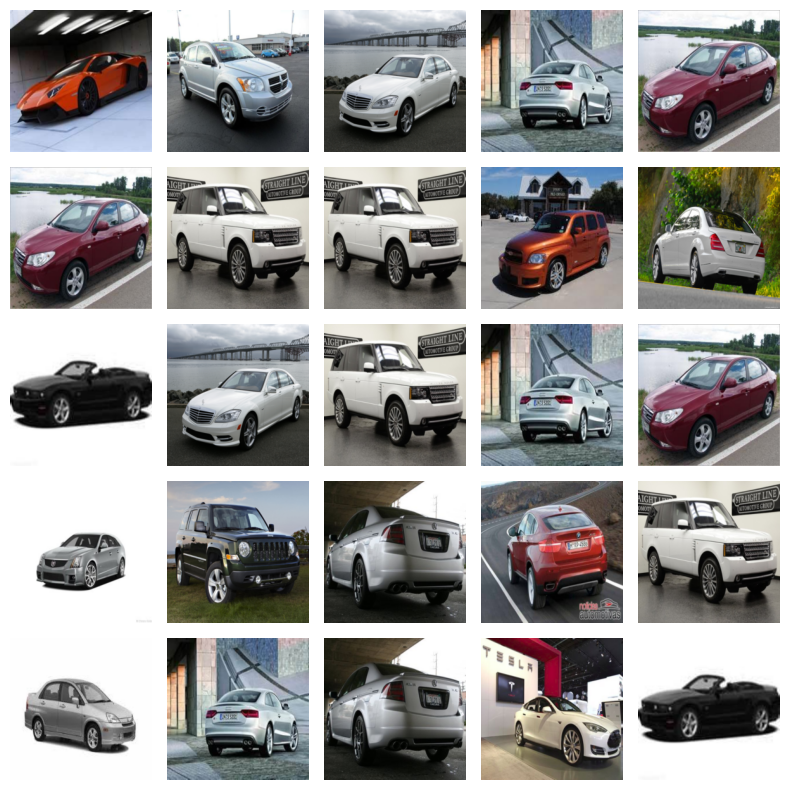

In [19]:
show_images(dataset)

Now we can import PyBSM and use it to model two different sensors collecting images of these cars.

In [20]:
from pybsm import simulation

Here we define a function which adds camera-specific distortion of the given focal length, telescope diameter, and bit-depth.

We create two torch transforms with identical parameters, except for bit depth. One sensor has a bit depth of 4 and the other has a bit depth of 8.


In [21]:
import copy


def apply_camera_distortion(image, f, D, bit_depth=100):
    p = 0.008e-3
    opt_trans_wavelengths = np.array([0.58 - 0.08, 0.58 + 0.08]) * 1.0e-6
    ihaze = 1
    altitude = 9000
    ground_range = 1000
    gsd_meters_per_px = 0.02
    image_array = np.array(image)
    reference_image = simulation.RefImage(
        img=image_array, gsd=gsd_meters_per_px
    )
    scenario = simulation.Scenario(
        name="virtual_camera1",
        ihaze=ihaze,
        altitude=altitude,
        ground_range=ground_range,
    )

    sensor = simulation.Sensor(
        name="virtual_camera1",
        D=D,
        f=f,
        p_x=p,
        opt_trans_wavelengths=opt_trans_wavelengths,
        bit_depth=bit_depth,
    )

    image_out = simulation.simulate_image(
        ref_img=reference_image,
        sensor=sensor,
        scenario=scenario,
    )[2]

    image_out = simulation.stretch_contrast_convert_8bit(img=image_out)

    return image_out


class Camera1:
    def __call__(self, image):
        f = 4
        D = 275e-3
        bit_depth = 4
        image_out = apply_camera_distortion(
            copy.deepcopy(image), f, D, bit_depth=bit_depth
        )
        return image_out


class Camera2:
    def __call__(self, image):
        f = 4
        D = 275e-3
        bit_depth = 8
        image_out = apply_camera_distortion(
            copy.deepcopy(image), f, D, bit_depth=bit_depth
        )
        return image_out


transform_camera1 = v2.Compose(
    [
        v2.Resize((224, 224)),
        GrayscaleToRGB(),
        Camera1(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

transform_camera2 = v2.Compose(
    [
        v2.Resize((224, 224)),
        GrayscaleToRGB(),
        Camera2(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

Here we see an example image transformed by camera 1.

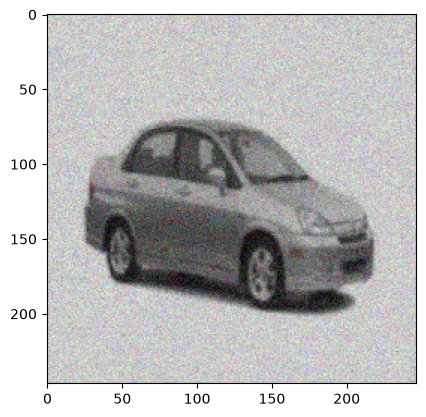

In [22]:
dataset.transform = transform_camera1

plt.figure()
image_camera1 = dataset[0]
plt.imshow(image_camera1)
plt.show()

Here we see an example image transformed by camera 2.

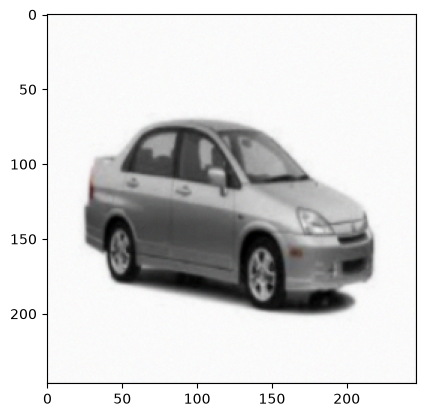

In [13]:
dataset.transform = transform_camera2

plt.figure()
image_camera2 = dataset[0]
plt.imshow(image_camera2)
plt.show()

Here we see several images transformed by each camera.

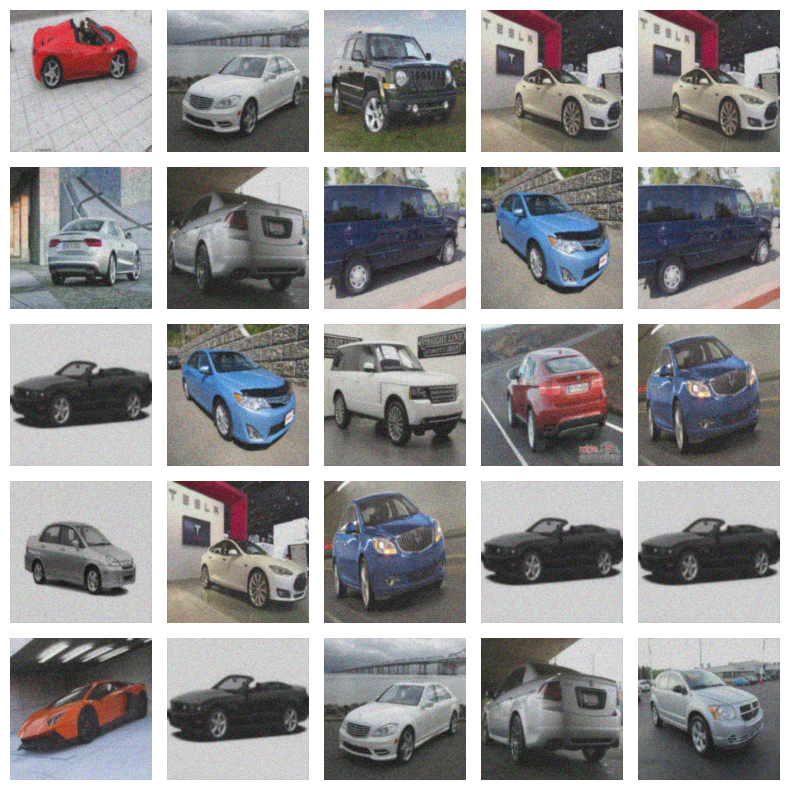

In [14]:
dataset.transform = transform_camera1
show_images(dataset)

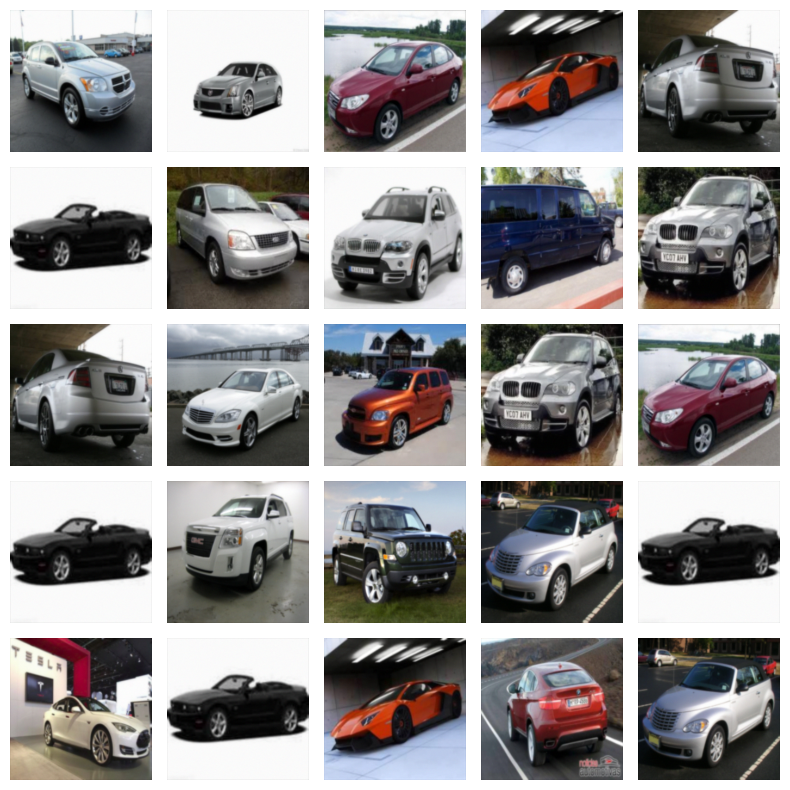

In [15]:
dataset.transform = transform_camera2
show_images(dataset)

Do you think you could tell if a forger tried to replace images collected with one sensor with images collected by the other in a court room?

Do you think an algorithm could tell?

What if you didn't have truth images, and the algorithm couldn't train on the images in question?